# Cointegration test via linear programming

In [29]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

tickers = ["JPM", "BAC", "C", "WFC", "GS", "MS"]
data = yf.download(tickers, start="2020-01-01", end="2025-01-01")["Close"]
data = data.dropna()
log_prices = np.log(data)

#prepare LP input
X = log_prices.values
dX = np.diff(X, axis=0)

C:\Users\nadia\AppData\Local\Temp\ipykernel_32544\2729553246.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end="2025-01-01")["Close"]
[*********************100%***********************]  6 of 6 completed


C:\Users\nadia\AppData\Local\Temp\ipykernel_32544\1616515194.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


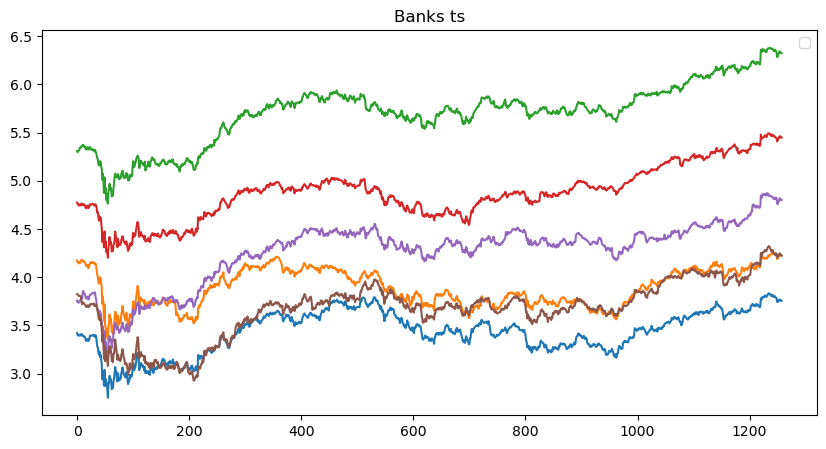

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(X)
plt.legend()
plt.title("Banks ts")
plt.show()

Optimal beta:
JPM: 0.7693
BAC: 0.1174
C: -3.0356
WFC: 1.3795
GS: 1.6432
MS: 0.1262


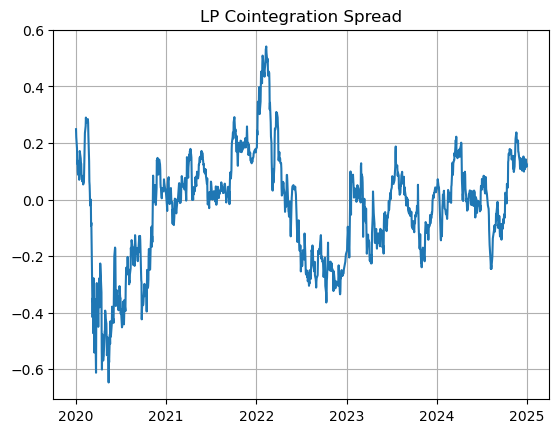

ADF statistic: -3.1082
p-value: 0.025951


In [32]:
#linear programming formulation

T_minus_1, n = X.shape

# Variables: beta (n) + u (T-1)
num_vars = n + T_minus_1

# Objective: minimize sum(u_t)
c = np.hstack([np.zeros(n), np.ones(T_minus_1)])

# Inequality constraints
A_ub = []
b_ub = []

for t in range(T_minus_1):
    # beta^T dX_t - u_t <= 0
    row = np.zeros(num_vars)
    row[:n] = X[t]
    row[n + t] = -1
    A_ub.append(row)
    b_ub.append(0)

    # -beta^T dX_t - u_t <= 0
    row = np.zeros(num_vars)
    row[:n] = -X[t]
    row[n + t] = -1
    A_ub.append(row)
    b_ub.append(0)

A_ub = np.array(A_ub)
b_ub = np.array(b_ub)

# Equality constraint: sum(beta) = 1
A_eq = np.zeros((1, num_vars))
A_eq[0, :n] = 1
b_eq = np.array([1])

# Bounds: beta free, u >= 0
bounds = [(None, None)] * n + [(0, None)] * T_minus_1

#Solve LP
#HIGHS - paskage which includes:
#highs-ds - dual simplex method 
#highs-jpm-interior-point method, faster for bvery large problems, but may not land exectly on a vertex
#highs - automatically chooses between ds and jpm 

res = linprog(c,
              A_ub=A_ub, b_ub=b_ub,
              A_eq=A_eq, b_eq=b_eq,
              bounds=bounds,
              method="highs")

if not res.success:
    raise ValueError("LP did not converge")

beta = res.x[:n]

print("Optimal beta:")
for t, b in zip(tickers, beta):
    print(f"{t}: {b:.4f}")

#Compute spread
spread = log_prices.values @ beta
plt.figure()
plt.plot(log_prices.index, spread)
plt.title("LP Cointegration Spread")
plt.grid(True)
plt.show()

#Stationarity test
adf_stat, pval, *_ = adfuller(spread)
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value: {pval:.6f}")


# Handling outliers

In [12]:
#tweak data to create oultiers
log_prices_out = log_prices.copy()

np.random.seed(42)
outlier_days = np.random.choice(len(log_prices), size=5, replace=False)

print("Outlier indices:", outlier_days)

# Inject shocks
for t in outlier_days:
    log_prices_out.iloc[t, 0] += 0.20   # +20% shock
    log_prices_out.iloc[t, 1] -= 0.25   # -25% shock

Outlier indices: [ 561  101   51   63 1073]


In [13]:
#OLS cointegration (Engle–Granger style)
#use one asset as dependent
import statsmodels.api as sm

def ols_beta(log_prices):
    y = log_prices.iloc[:, 0]
    X = log_prices.iloc[:, 1:]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    beta = np.zeros(log_prices.shape[1])
    beta[0] = 1
    beta[1:] = -model.params[1:]
    
    return beta

beta_ols_clean = ols_beta(log_prices)
beta_ols_out = ols_beta(log_prices_out)

In [14]:
beta_ols_clean


array([ 1.        , -0.59691255, -0.15682217,  0.43859317, -0.33003195,
       -0.29259874])

In [15]:
beta_ols_out

array([ 1.        , -0.56749273, -0.14485564,  0.41786429, -0.31688569,
       -0.30910068])

In [33]:
def lp_beta(log_prices):
    X = log_prices.values
    dX = np.diff(X, axis=0)
    Tm1, n = X.shape

    num_vars = n + Tm1
    c = np.hstack([np.zeros(n), np.ones(Tm1)])

    A_ub, b_ub = [], []

    for t in range(Tm1):
        row = np.zeros(num_vars)
        row[:n] = X[t]
        row[n+t] = -1
        A_ub.append(row)
        b_ub.append(0)

        row = np.zeros(num_vars)
        row[:n] = -X[t]
        row[n+t] = -1
        A_ub.append(row)
        b_ub.append(0)

    A_eq = np.zeros((1, num_vars))
    A_eq[0, :n] = 1
    b_eq = np.array([1])

    bounds = [(None, None)] * n + [(0, None)] * Tm1

    res = linprog(c,
                  A_ub=np.array(A_ub), b_ub=np.array(b_ub),
                  A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds,
                  method="highs")

    return res.x[:n]

beta_lp_clean = lp_beta(log_prices)
beta_lp_out = lp_beta(log_prices_out)

In [34]:
print("=== OLS change ===")
print(beta_ols_out - beta_ols_clean)

print("\n=== LP change ===")
print(beta_lp_out - beta_lp_clean)

=== OLS change ===
[ 0.          0.02941982  0.01196653 -0.02072887  0.01314626 -0.01650194]

=== LP change ===
[ 0.01114389 -0.00768837 -0.00175367  0.00654128 -0.00064505 -0.00759807]


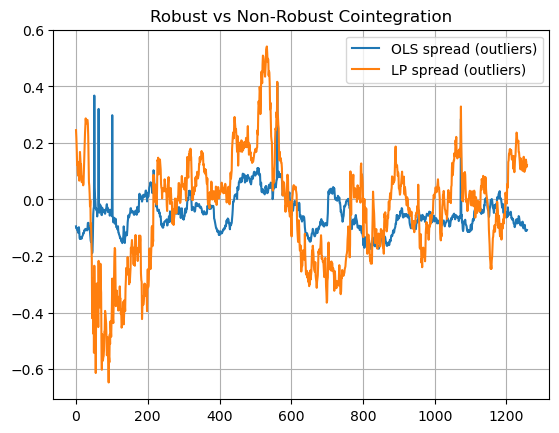

In [35]:
def compute_spread(log_prices, beta):
    return log_prices.values @ beta

spread_ols_out = compute_spread(log_prices_out, beta_ols_out)
spread_lp_out = compute_spread(log_prices_out, beta_lp_out)

plt.figure()
plt.plot(spread_ols_out, label="OLS spread (outliers)")
plt.plot(spread_lp_out, label="LP spread (outliers)")
plt.legend()
plt.title("Robust vs Non-Robust Cointegration")
plt.grid(True)
plt.show()